In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("DHL_Shipment_Data.csv")

In [ ]:
print(df.shape)
print(df.size)
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())
print(df.isnull().sum())

(2802, 15)
42030
   delivery_id delivery_partner package_type vehicle_type delivery_mode  \
0       250.99              dhl  electronics       ev van      same day   
1       250.99              dhl     clothing          van       two day   
2       250.99              dhl  electronics      scooter       two day   
3       250.99              dhl     clothing      ev bike       express   
4       250.99              dhl    furniture         bike       two day   

  region weather_condition  distance_km  package_weight_kg  \
0   east              cold        269.7              12.69   
1  north             foggy        256.7              37.02   
2   west            stormy        217.9              14.08   
3   east             foggy        293.8              41.03   
4   east             rainy        291.4               6.12   

             delivery_time_hours            expected_time_hours delayed  \
0  1970-01-01 00:00:00.000000006  1970-01-01 00:00:00.000000008      no   
1  1970-0

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna(method="ffill", inplace=True)

print(df.isnull().sum())

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64


/tmp/ipykernel_1293/1929758783.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


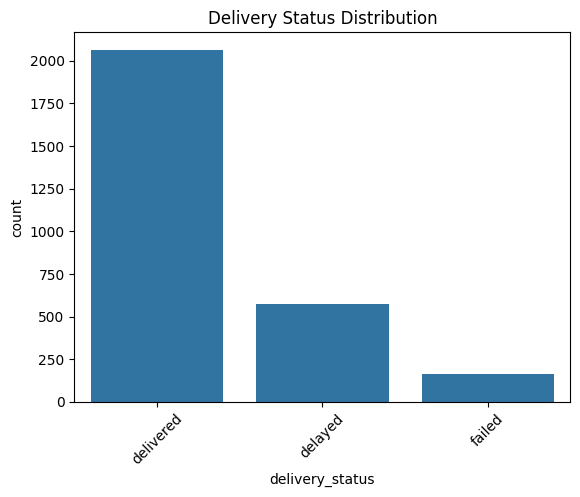

In [ ]:
# Delivery Status
sns.countplot(x="delivery_status", data=df)
plt.title("Delivery Status Distribution")
plt.xticks(rotation=45)
plt.show()

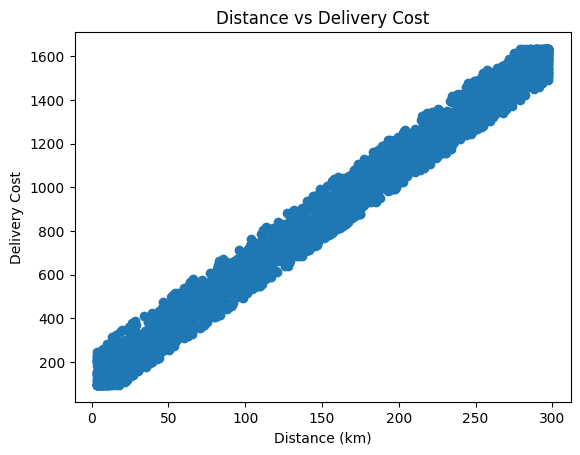

In [ ]:
plt.scatter(df["distance_km"], df["delivery_cost"])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")
plt.title("Distance vs Delivery Cost")
plt.show()

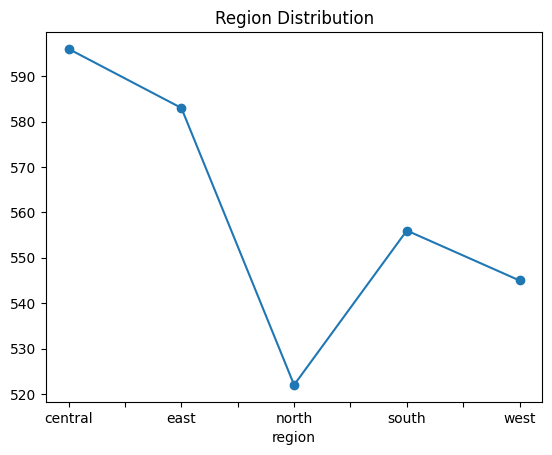

In [ ]:
# Region distribution #Line Chart
df["region"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Region Distribution")
plt.show()

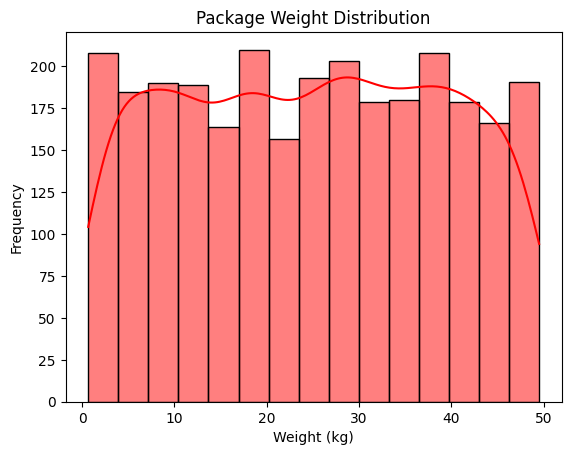

In [ ]:
# Histogram Package Weight
sns.histplot(df["package_weight_kg"], bins=15, kde=True, color="Red")
plt.title("Package Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

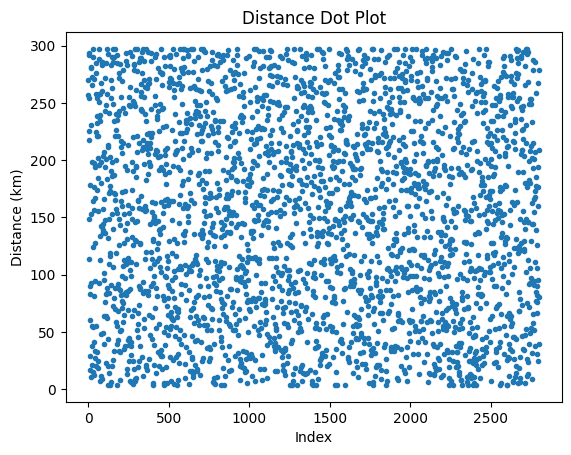

In [ ]:
# Dot Plot
plt.plot(df["distance_km"], ".", markersize=6)
plt.title("Distance Dot Plot")
plt.xlabel("Index")
plt.ylabel("Distance (km)")
plt.show()

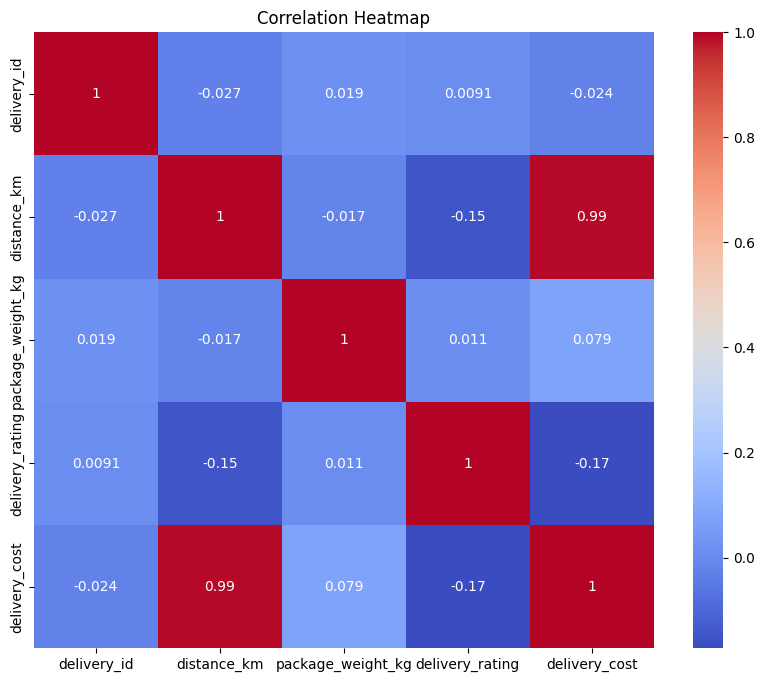

In [ ]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

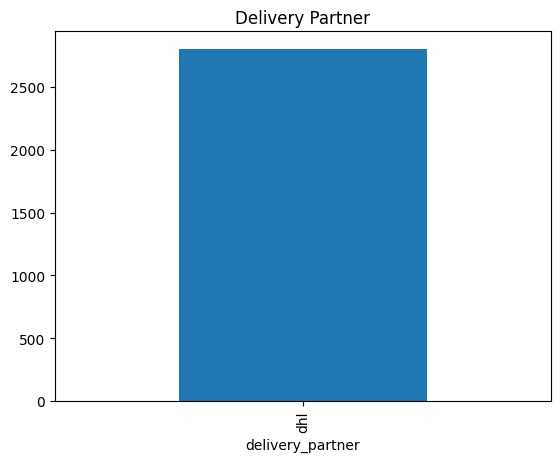

In [ ]:
# Bar Chart
df["delivery_partner"].value_counts().plot(kind="bar")
plt.title("Delivery Partner")
plt.show()


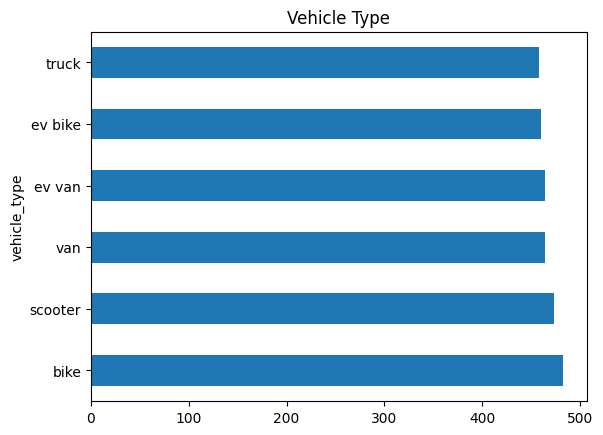

In [ ]:
# Horizontal Bar Chart

df["vehicle_type"].value_counts().plot(kind="barh")
plt.title("Vehicle Type")
plt.show()

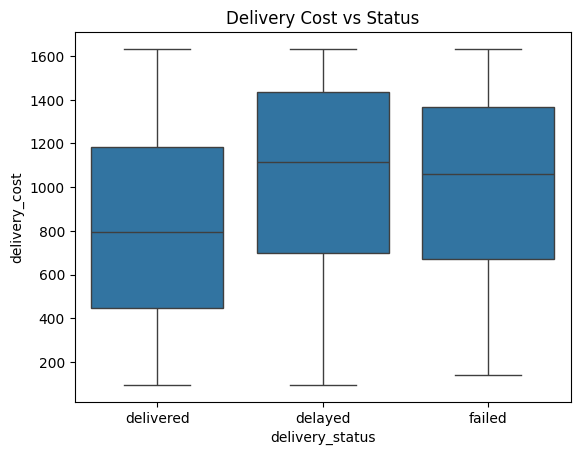

In [ ]:
# Box Plot
sns.boxplot(x="delivery_status", y="delivery_cost", data=df)
plt.title("Delivery Cost vs Status")
plt.show()

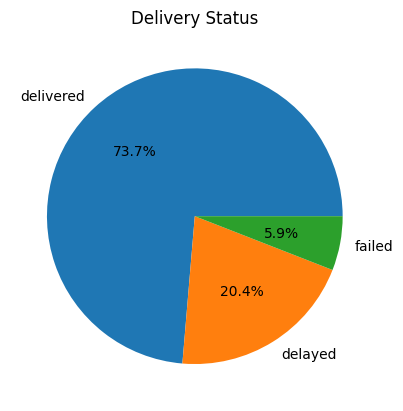

In [ ]:
# Pie Chart
df["delivery_status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Delivery Status")
plt.show()

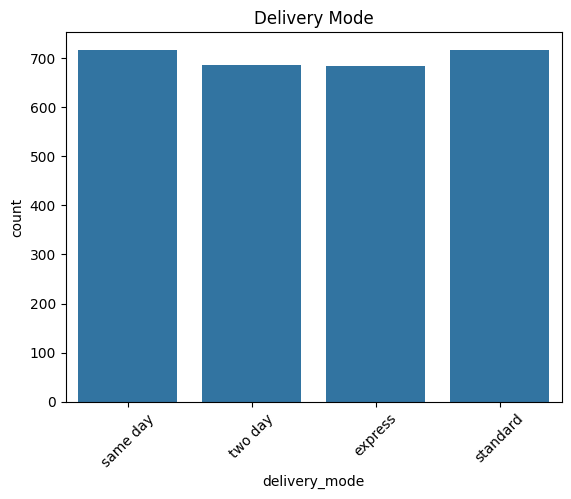

In [ ]:
#Count Plot
sns.countplot(x="delivery_mode", data=df)
plt.title("Delivery Mode")
plt.xticks(rotation=45)
plt.show()

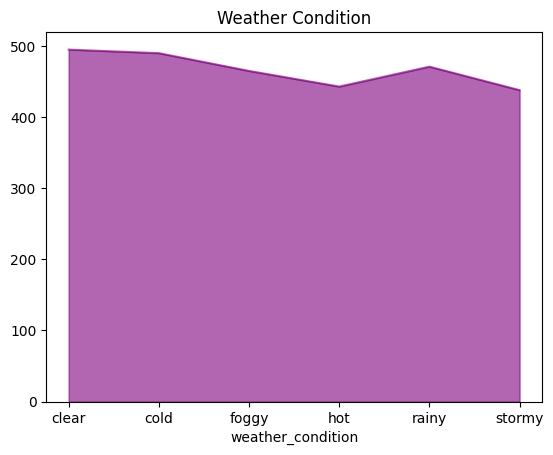

In [ ]:
#Area Chart
df["weather_condition"].value_counts().sort_index().plot(
    kind="area",
    color="purple",
    alpha=0.6
)
plt.title("Weather Condition")
plt.show()

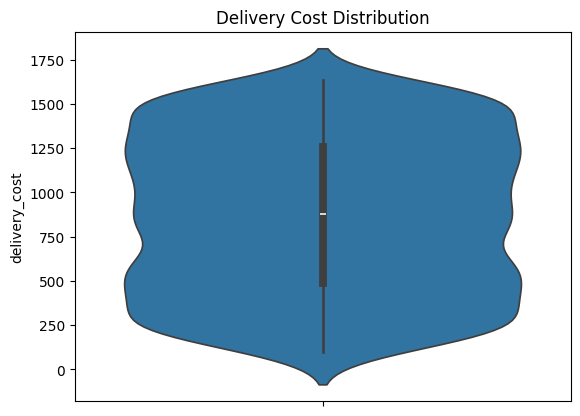

In [ ]:
#Violin Plot
sns.violinplot(y=df["delivery_cost"])
plt.title("Delivery Cost Distribution")
plt.show()

In [ ]:
# DATA PREPROCESSING
if "delivery_id" in df.columns:
    df.drop("delivery_id", axis=1, inplace=True)

# Categorical columns ko numeric me convert karo
df = pd.get_dummies(df, drop_first=True)

# Target variable
X = df.drop("delayed_yes", axis=1)
y = df["delayed_yes"]

In [ ]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# FEATURE SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# EVALUATION
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       412
        True       1.00      1.00      1.00       149

    accuracy                           1.00       561
   macro avg       1.00      1.00      1.00       561
weighted avg       1.00      1.00      1.00       561



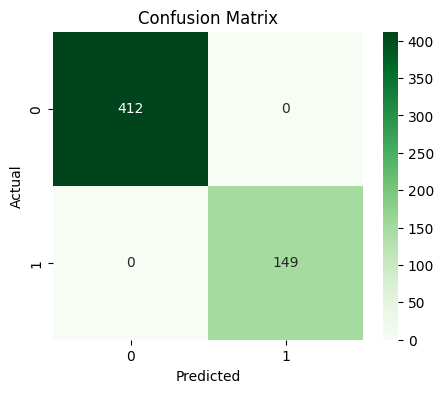

In [ ]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC AUC Score: 1.0


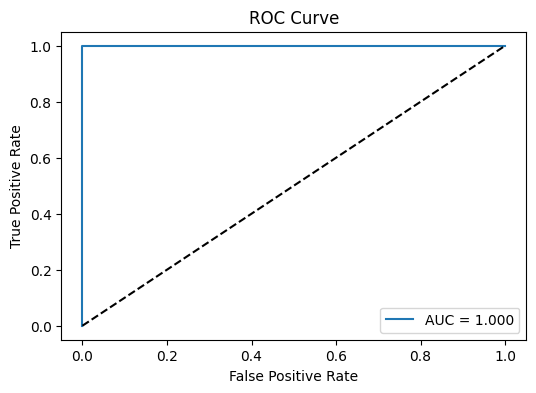

In [ ]:
#ROC and AUC CUrve
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_prob[:,1])
print("ROC AUC Score:", auc)
fpr, tpr, threshold = roc_curve(y_test, y_prob[:,1])

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       412
        True       1.00      1.00      1.00       149

    accuracy                           1.00       561
   macro avg       1.00      1.00      1.00       561
weighted avg       1.00      1.00      1.00       561

